In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import random
import torch

<h1>Detectron 2</h1>
the following code is set to be used in google colab, connected to your google drive, and holding the AgroPestData.zip in a folder called agropestData. There is also code to use dataset_distorted.zip, which need not be run if dataset_distorted.zip is unavailable to you. Running the model training can take upwards of 4 hours on the high end GPUs in google colab for 6000 iterations. Plan accordingly.

Import google drive to google colab to access models and images

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


unzip zipped agropest12 and distorted test image folders from google drive content folder

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/agropestData/AgroPestData.zip"
extract_dir = "/content/AgroPest12"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Extracted successfully to:", extract_dir)

✅ Extracted successfully to: /content/AgroPest12


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/agropestData/dataset_distorted.zip"
extract_dir = "/content/DistortedAgroPest12"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Extracted successfully to:", extract_dir)

✅ Extracted successfully to: /content/DistortedAgroPest12


Setup paths for data from AgroPest folders

In [ ]:
BASE = "/content/AgroPest12"
TRAIN_IMAGES = f"{BASE}/train/images"
TRAIN_LABELS = f"{BASE}/train/labels"

VAL_IMAGES = f"{BASE}/valid/images"
VAL_LABELS = f"{BASE}/valid/labels"

TEST_IMAGES = f"{BASE}/test/images"
TEST_LABELS = f"{BASE}/test/labels"

DATA_YAML = f"{BASE}/data.yaml"

make distorted image set paths

In [ ]:
MDISBASE = "/content/DistortedAgroPest12/dataset_distorted/dataset_mild_distortion"
MDISTRAIN_IMAGES = f"{MDISBASE}/test/images"
MDISTRAIN_LABELS = f"{MDISBASE}/test/labels"

SDISBASE = "/content/DistortedAgroPest12/dataset_distorted/dataset_strong_distortion"
SDISTRAIN_IMAGES = f"{SDISBASE}/test/images"
SDISTRAIN_LABELS = f"{SDISBASE}/test/labels"
DATA_YAML = f"{MDISBASE}/data_mild.yaml"

In [ ]:
import yaml
with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

CLASSES = data["names"]
print("Classes:", CLASSES)

Classes: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']


# The following function converts general YOLO folder style into a COCO.json to support detectron2. It also sets the number of training images

In [ ]:

def make_coco(img_dir, label_dir, output_json, classes):
    valid_exts = {".jpg", ".jpeg", ".png"}

    coco = {
        "info": {
            "description": "AgroPest-12 dataset",
            "url": "",
            "version": "1.0",
            "year": 2025,
            "contributor": "",
            "date_created": "2025-11-09"
        },
        "licenses": [
            {
                "id": 1,
                "name": "Unknown",
                "url": ""
            }
        ],
        "images": [],
        "annotations": [],
        "categories": []
    }

    for i, cls in enumerate(classes):
        coco["categories"].append({
            "id": i+1,
            "name": cls,
            "supercategory": "insect"

        })
    ann_id = 1
    img_id = 1

    #sort files and set training data size. Here it is set to 6000
    files = sorted(os.listdir(img_dir))
    random.shuffle(files)
    files = files[:len(files)//2]

    for filename in files:
        ext = os.path.splitext(filename)[1].lower()
        if ext not in valid_exts:
            continue

        image_path = os.path.join(img_dir, filename)
        img = cv2.imread(image_path)

        if img is None:
            print("skipping unreadable image", filename)
            continue

        h, w = img.shape[:2]
        coco["images"].append({
            "id": img_id,
            "file_name": filename,
            "width": w,
            "height": h
        })

        ann_path = os.path.join(label_dir, os.path.splitext(filename)[0] + ".txt")

        if os.path.exists(ann_path):
            with open(ann_path, "r") as f:
                for line in f:
                    cls, cx, cy, bw, bh = map(float, line.split())

                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    bw *= w
                    bh *= h

                    coco["annotations"].append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": int(cls)+1,
                        "bbox": [x1, y1, bw, bh],
                        "area": bw * bh,
                        "iscrowd": 0
                    })
                    ann_id += 1

        img_id += 1

    with open(output_json, "w") as f:
        json.dump(coco, f, indent=2)

    print("COCO File created:", output_json)

# Install Pytorch and Detectron 2

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip uninstall -y detectron2
!pip install 'git+https://github.com/facebookresearch/detectron2.git'


import detectron2
print(detectron2.__version__)

Looking in indexes: https://download.pytorch.org/whl/cu121
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-t9vpj1vc
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-t9vpj1vc
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 81.2 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=6733234 sha256=ee74d06f54c23057325dbf4a4ac491bc9263a6dc515fc0c46009600f6224c64b
  Stored in directory: /tmp/pip-

# Create COCO json files

In [ ]:

make_coco(TRAIN_IMAGES, TRAIN_LABELS, f"{BASE}/train.json", CLASSES)
make_coco(VAL_IMAGES, VAL_LABELS, f"{BASE}/val.json", CLASSES)
make_coco(TEST_IMAGES, TEST_LABELS, f"{BASE}/test.json", CLASSES)

COCO File created: /content/AgroPest12/train.json
COCO File created: /content/AgroPest12/val.json
COCO File created: /content/AgroPest12/test.json


In [ ]:
make distorted image set cocos

In [ ]:
make_coco(MDISTRAIN_IMAGES, MDISTRAIN_LABELS, f"{MDISBASE}/test/mdtest.json", CLASSES)
make_coco(SDISTRAIN_IMAGES, SDISTRAIN_LABELS, f"{SDISBASE}/test/stest.json", CLASSES)

COCO File created: /content/DistortedAgroPest12/dataset_distorted/dataset_mild_distortion/test/mdtest.json
COCO File created: /content/DistortedAgroPest12/dataset_distorted/dataset_strong_distortion/test/stest.json


# Register detectron instances

In [ ]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances("argo_train", {}, f"{BASE}/train.json", TRAIN_IMAGES)
register_coco_instances("argo_val", {}, f"{BASE}/val.json", VAL_IMAGES)
register_coco_instances("argo_test", {}, f"{BASE}/test.json", TEST_IMAGES)



register distorted imageset

In [ ]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances("mdtest", {}, f"{MDISBASE}/test/mdtest.json", MDISTRAIN_IMAGES)
register_coco_instances("stest", {},f"{SDISBASE}/test/stest.json", SDISTRAIN_IMAGES)

# MODEL TRAINING

The following trainer uses a custom mapper to augment images via resizing, flipping and adjusting contrast, brightness and saturation. Then in the configuration section, we begin by loading the faster_rcnn_R_101 model, which is better that the the R_50 model. The solver Amp is deprecated on this version of torch, so it is set to false and replaced with torch.set_float32_matmul_precision to increase performance. On other versions of torch and detectron, the AMP can improved performance by almost 50%.

After setting our datasets and model weights, we run 60,000 iterations on 6000 images at a learn rate of 0.001, which was determined to be optimal after testing. We also set ROI heads, to accurately map regions of interest. below that, I commented out the anchor weights and image sizes we were testing on. I found AP was better without them.
Lastly, we set a checkpoint every 5000 iterations, an output folder and set a trainer that uses our custom mapper function.

In [ ]:
import os
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data import detection_utils as utils
from detectron2.data import transforms as T
from detectron2.data import build_detection_train_loader
from detectron2.data import DatasetMapper


# Custom mapper for augmenting images in training
def custom_mapper(dataset_dict):
    dataset_dict = dataset_dict.copy()
    image = utils.read_image(dataset_dict["file_name"], format="BGR")
    aug = [
            T.ResizeShortestEdge((640, 720, 800, 900, 1000), max_size=1536, sample_style="choice"),
            T.RandomFlip(horizontal=True, vertical=False),
            T.RandomContrast(0.7, 1.3),
            T.RandomBrightness(0.7, 1.3),
            T.RandomSaturation(0.7, 1.3),
    ]

    image, transforms = T.apply_transform_gens(aug, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))
    annos = [
        utils.transform_instance_annotations(obj, transforms, image.shape[:2])
        for obj in dataset_dict.pop("annotations")
    ]
    dataset_dict["instances"] = utils.annotations_to_instances(annos, image.shape[:2])
    return dataset_dict

# Configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml"))


cfg.MODEL.DEVICE = "cuda"
cfg.SOLVER.AMP.ENABLED = False
torch.set_float32_matmul_precision('medium')

# Datasets
cfg.DATASETS.TRAIN = ("argo_train",)
cfg.DATASETS.TEST = ("argo_test",)

# Model weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml")

# Solver
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.DATALOADER.NUM_WORKERS = 4
cfg.SOLVER.BASE_LR = 0.0001
cfg.MODEL.ROI_HEADS.LOSS_WEIGHT = 2.0
cfg.SOLVER.MAX_ITER = 60000
cfg.SOLVER.STEPS = (40000, 50000)

# ROI heads
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 12
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256
cfg.MODEL.ROI_HEADS.POSITIVE_FRACTION = 0.7
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.2

#unused anchosrs and image sizes
#cfg.MODEL.ANCHOR_GENERATOR.SIZES = [[32, 64, 128, 256, 512]]
#cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [[0.5, 1.0, 2.0]]

#cfg.INPUT.MIN_SIZE_TRAIN = (800, 1000, 1200)
#cfg.INPUT.MAX_SIZE_TRAIN = 1600


cfg.INPUT.FORMAT = "BGR"
cfg.TEST.EVAL_PERIOD = 0
cfg.SOLVER.CHECKPOINT_PERIOD = 5000
cfg.OUTPUT_DIR = "/content/drive/MyDrive/agropestData"

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

class MyTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        return build_detection_train_loader(cfg, mapper=custom_mapper)


# Train
trainer = MyTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()



[11/15 03:52:10 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

LOAD MODEL INSTEAD OF TRAINING

In [ ]:
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog
import cv2
import os

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/agropestData/model_test_47_60000_saved.pth"

if not os.path.exists(cfg.MODEL.WEIGHTS):
    print(f"Model not found at: {cfg.MODEL.WEIGHTS}")

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 12
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

predictor = DefaultPredictor(cfg)

# Evaluate model AP
creates a simple COCOEvaluator, that tests the code on the test dataset and outputs average precision inference.

In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.data import DatasetCatalog, MetadataCatalog
import time
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve

#Set test directory for prediction
evaluator = COCOEvaluator("argo_test", cfg, False)
val_loader = build_detection_test_loader(cfg, "argo_test")
results = inference_on_dataset(predictor.model, val_loader, evaluator)
print(results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.438
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.765
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.456
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.094
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.466
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.481
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.508
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.508
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.093
 Average Recall     (AR) @[ IoU=0.50:

#Load and test an image's bboxes and classification from test library

Class: Slugs, Score: 0.955
Class: Earthworms, Score: 0.285
Class: Earthworms, Score: 0.062
Class: Earthworms, Score: 0.024
Class: Earthworms, Score: 0.022
Class: Earthworms, Score: 0.022
Class: Earthworms, Score: 0.019
Class: Earthworms, Score: 0.019
Class: Earthworms, Score: 0.019
Class: Earthworms, Score: 0.018
Class: Earthworms, Score: 0.017
Class: Earthworms, Score: 0.015
Class: Snails, Score: 0.014
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.013
Class: Earthworms, Score: 0.013
Class: Earthworms, Score: 0.013
Class: Earthworms, Score: 0.011
Class: Earthworms, Score: 0.010
Class: Earthworms, Score: 0.010
Predicted class IDs: tensor([8, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 9, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4])
Confidence scores: tensor([0.9547, 0.2849, 0.0619, 0.0244, 0.0223, 0.0218, 0.0191, 0.0188, 0.018

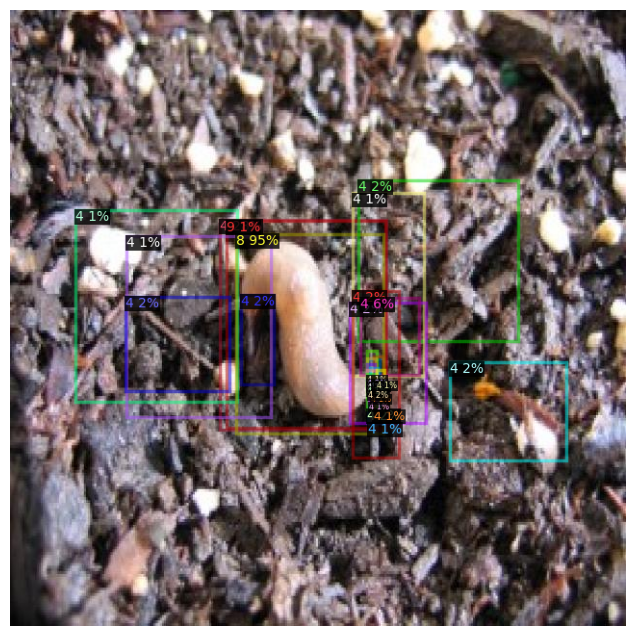

In [ ]:
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.01
predictor = DefaultPredictor(cfg)


file = random.choice(os.listdir(TEST_IMAGES))
img_path = os.path.join(TEST_IMAGES, file)

img = cv2.imread(img_path)
outputs = predictor(img)

instances = outputs["instances"].to("cpu")

pred_classes = instances.pred_classes
scores = instances.scores

for cls_id, score in zip(pred_classes, scores):
    print(f"Class: {CLASSES[int(cls_id)]}, Score: {score:.3f}")
print("Predicted class IDs:", pred_classes)
print("Confidence scores:", scores)

v = Visualizer(img[:, :, ::-1], scale=1.0)
vis = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(12, 8))
plt.imshow(vis.get_image())
plt.axis('off')
plt.show()


#Save model to path (after training only)

In [ ]:

final_path = os.path.join(cfg.OUTPUT_DIR, "model_test_47_60000_saved.pth")
torch.save(trainer.model.state_dict(), final_path)
print("Model saved to:", final_path)

NameError: name 'trainer' is not defined

#ANALYSE RESULTS

Set the test dataset and ROI thresh test

In [ ]:

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.05
cfg.DATASETS.TEST = ("argo_test",)


Calculate metrics and plot graphs into a full report

Test dataset size: 273
Classes: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']



Processing: 100%|██████████| 273/273 [00:34<00:00,  7.96it/s]



Total samples: 341
With predictions: 326
False negatives: 15

OVERALL CLASSIFICATION METRICS
Accuracy:  85.28%
Precision: 86.84%
Recall:    85.28%
F1 Score:  85.21%
AUC (Macro):    0.9274 (92.74%)
AUC (Weighted): 0.9234 (92.34%)

PER-CLASS METRICS
Class           | Precision  | Recall     | F1 Score   |  AUC        | Support
--------------------------------------------------------------------------------
Ants            |  70.27%    |  89.66%   |  78.79%    | 29
Bees            |  95.83%    |  92.00%   |  93.88%    | 25
Beetles         |  64.00%    |  80.00%   |  71.11%    | 20
Caterpillars    |  76.19%    |  88.89%   |  82.05%    | 36
Earthworms      |  92.31%    |  80.00%   |  85.71%    | 15
Earwigs         |  86.67%    |  72.22%   |  78.79%    | 36
Grasshoppers    |  95.65%    |  59.46%   |  73.33%    | 37
Moths           |  94.74%    |  90.00%   |  92.31%    | 20
Slugs           |  73.91%    |  89.47%   |  80.95%    | 19
Snails          |  96.77%    |  96.77%   |  96.77%    | 31
W

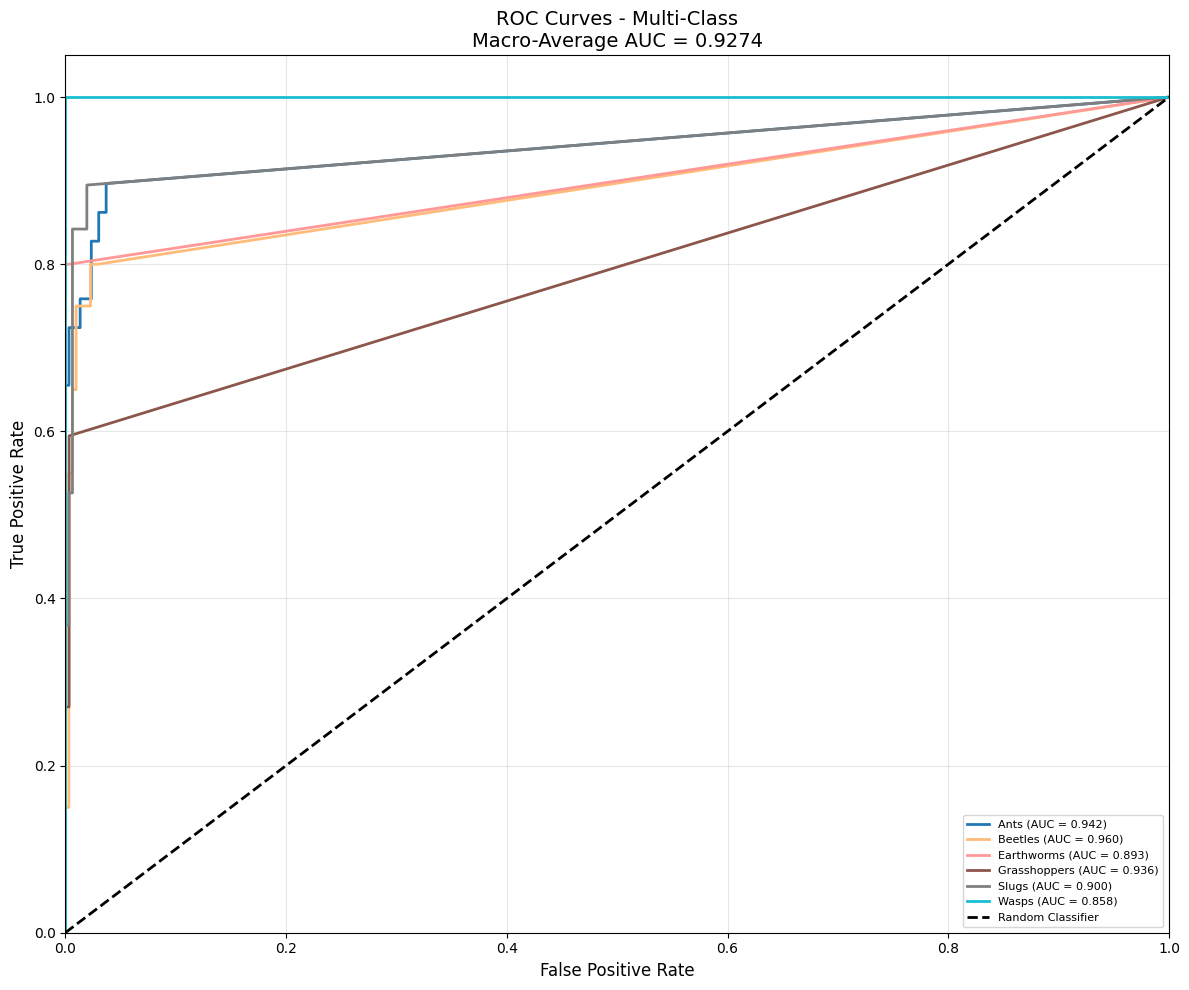

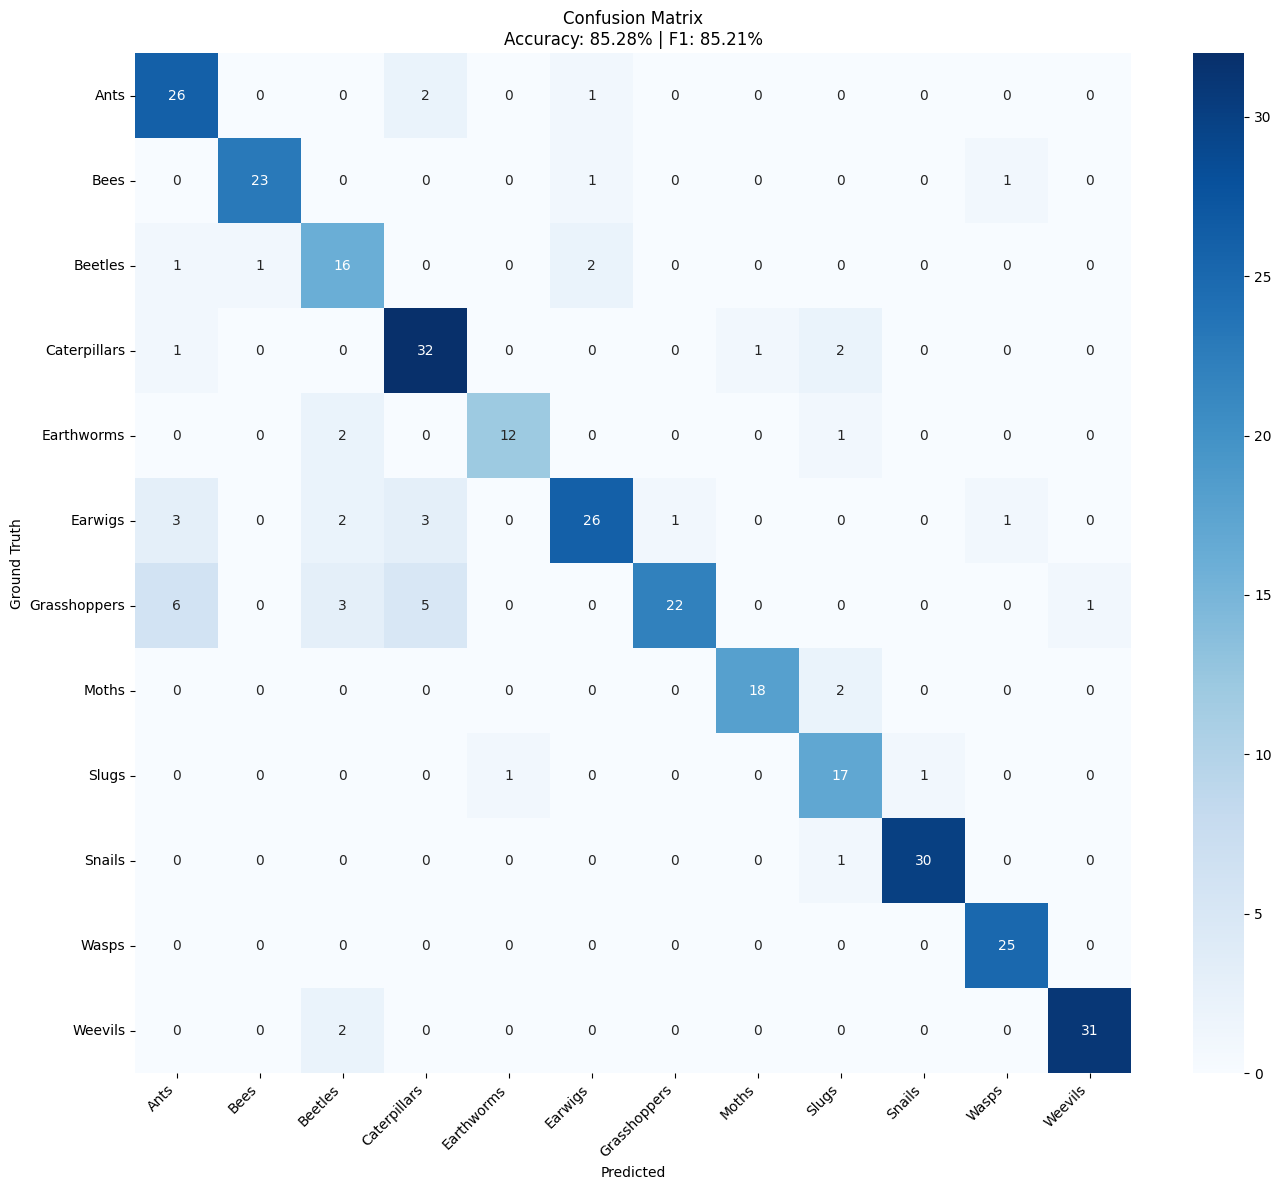

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from detectron2.engine import DefaultPredictor
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.structures import Boxes, pairwise_iou
import torch


# Get test dataset images
test_dataset = DatasetCatalog.get(cfg.DATASETS.TEST[0])
metadata = MetadataCatalog.get(cfg.DATASETS.TEST[0])

print(f"Test dataset size: {len(test_dataset)}")
print(f"Classes: {metadata.thing_classes}\n")

y_true = []
y_pred = []
y_scores = []
iou_threshold = 0.5

# Process each image and record data
for d in tqdm(test_dataset, desc="Processing"):
    img = cv2.imread(d["file_name"])
    if img is None or len(d["annotations"]) == 0:
        continue

    outputs = predictor(img)
    instances = outputs["instances"]

    if len(instances) == 0:
        continue

    pred_boxes = instances.pred_boxes
    pred_classes = instances.pred_classes.cpu().numpy()
    pred_scores_raw = instances.scores.cpu().numpy()

    # Get ground truth
    gt_boxes_xywh = [ann["bbox"] for ann in d["annotations"]]
    gt_classes = [ann["category_id"] for ann in d["annotations"]]

    # Convert GT boxes to [x1, y1, x2, y2] on same device as predictions
    gt_boxes_xyxy = []
    for box in gt_boxes_xywh:
        x, y, w, h = box
        gt_boxes_xyxy.append([x, y, x + w, y + h])

    #Put GT boxes on same device as predictions
    device = pred_boxes.device
    gt_boxes_xyxy = torch.tensor(gt_boxes_xyxy, dtype=torch.float32, device=device)
    gt_boxes = Boxes(gt_boxes_xyxy)

    # Compute IoU
    iou_matrix = pairwise_iou(pred_boxes, gt_boxes).cpu().numpy()

    # Match predictions to GT
    matched_gt = set()
    for pred_idx in range(len(pred_classes)):
        if len(gt_classes) == 0:
            break

        ious = iou_matrix[pred_idx]
        best_gt_idx = np.argmax(ious)
        best_iou = ious[best_gt_idx]

        if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
            y_true.append(gt_classes[best_gt_idx])
            y_pred.append(pred_classes[pred_idx])
            y_scores.append(pred_scores_raw[pred_idx])
            matched_gt.add(best_gt_idx)

    # False negatives
    for gt_idx, gt_cls in enumerate(gt_classes):
        if gt_idx not in matched_gt:
            y_true.append(gt_cls)
            y_pred.append(-1)
            y_scores.append(0.0)

#Print predictions with false negatives
print(f"\nTotal samples: {len(y_true)}")
print(f"With predictions: {sum(1 for p in y_pred if p != -1)}")
print(f"False negatives: {sum(1 for p in y_pred if p == -1)}\n")

# Filter out false negatives
valid_mask = np.array(y_pred) != -1
y_true_filtered = np.array(y_true)[valid_mask]
y_pred_filtered = np.array(y_pred)[valid_mask]
y_scores_filtered = np.array(y_scores)[valid_mask]

y_true_binary = label_binarize(y_true_filtered, classes=range(12))

y_scores_binary = np.zeros((len(y_pred_filtered), 12))
for i, (pred_class, score) in enumerate(zip(y_pred_filtered, y_scores_filtered)):
    y_scores_binary[i, pred_class] = score

auc_per_class = []
fpr_per_class = {}
tpr_per_class = {}

for i in range(12):
  if y_true_binary[:, i].sum() > 0:
    try:
      fpr, tpr, _ = roc_curve(y_true_binary[:, i], y_scores_binary[:, i])
      roc_auc = auc(fpr, tpr)
      auc_per_class.append(roc_auc)
      fpr_per_class[i] = fpr
      tpr_per_class[i] = tpr
    except:
      auc_per_class.append(0.0)
    else:
      auc_per_class.append(0.0)


# Calculate macro-average AUC (average across classes)
macro_auc = np.mean([a for a in auc_per_class if a > 0])

# Calculate Weighted AUC (by class support)
try:
  weighted_auc = roc_auc_score(y_true_binary, y_scores_binary,
                              average='weighted', multi_class='ovr')
except:
  weighted_auc = macro_auc

if len(y_true_filtered) > 0:

    # Compute metrics
    accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
    precision = precision_score(y_true_filtered, y_pred_filtered, average='weighted', zero_division=0)
    recall = recall_score(y_true_filtered, y_pred_filtered, average='weighted', zero_division=0)
    f1 = f1_score(y_true_filtered, y_pred_filtered, average='weighted', zero_division=0)

    print("="*80)
    print("OVERALL CLASSIFICATION METRICS")
    print("="*80)
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1 Score:  {f1*100:.2f}%")
    print(f"AUC (Macro):    {macro_auc:.4f} ({macro_auc*100:.2f}%)")
    print(f"AUC (Weighted): {weighted_auc:.4f} ({weighted_auc*100:.2f}%)")
    print("="*80)

    # Confusion matrix
    cm = confusion_matrix(y_true_filtered, y_pred_filtered,
                         labels=range(len(metadata.thing_classes)))

    # Per-class metrics
    print("\n" + "="*80)
    print("PER-CLASS METRICS")
    print("="*80)
    print(f"{'Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10} |  {'AUC':<10} | Support")
    print("-"*80)

    for i, class_name in enumerate(metadata.thing_classes):
        if cm[i].sum() > 0:
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp

            prec = tp / (tp + fp) if (tp + fp) > 0 else 0
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1_class = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            print(f"{class_name:<15} | {prec*100:>6.2f}%    | {rec*100:>6.2f}%   | "
                  f"{f1_class*100:>6.2f}%    | {int(cm[i].sum())}")

    print("="*80)

    plt.figure(figsize=(12, 10))

    # Plot ROC curve for each class
    colors = plt.cm.tab20(np.linspace(0, 1, 12))

    for i, (class_name, color) in enumerate(zip(metadata.thing_classes, colors)):
        if i in fpr_per_class and auc_per_class[i] > 0:
            plt.plot(fpr_per_class[i], tpr_per_class[i], color=color, lw=2,
                    label=f'{class_name} (AUC = {auc_per_class[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - Multi-Class\nMacro-Average AUC = {macro_auc:.4f}', fontsize=14)
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot confusion matrix
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=metadata.thing_classes,
                yticklabels=metadata.thing_classes)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.title(f"Confusion Matrix\nAccuracy: {accuracy*100:.2f}% | F1: {f1*100:.2f}%")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

else:
    print("No valid predictions found!")

#Demo code
set image path to any image of insect and run on model to see it classify insect.

Class: Earthworms, Score: 0.992
Class: Earthworms, Score: 0.918
Class: Beetles, Score: 0.495
Class: Earthworms, Score: 0.391
Class: Caterpillars, Score: 0.294
Class: Earthworms, Score: 0.276
Class: Earthworms, Score: 0.126
Class: Earthworms, Score: 0.082
Class: Earthworms, Score: 0.056
Class: Earthworms, Score: 0.056
Class: Earthworms, Score: 0.047
Class: Earthworms, Score: 0.045
Class: Earthworms, Score: 0.044
Class: Earthworms, Score: 0.043
Class: Caterpillars, Score: 0.033
Class: Earthworms, Score: 0.030
Class: Earthworms, Score: 0.027
Class: Caterpillars, Score: 0.025
Class: Earthworms, Score: 0.024
Class: Earthworms, Score: 0.024
Class: Earthworms, Score: 0.023
Class: Earthworms, Score: 0.023
Class: Caterpillars, Score: 0.017
Class: Grasshoppers, Score: 0.017
Class: Earthworms, Score: 0.017
Class: Caterpillars, Score: 0.016
Class: Earthworms, Score: 0.015
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.014
Class: Earthworms, Score: 0.012
Class: Earthworms, Score: 0.011

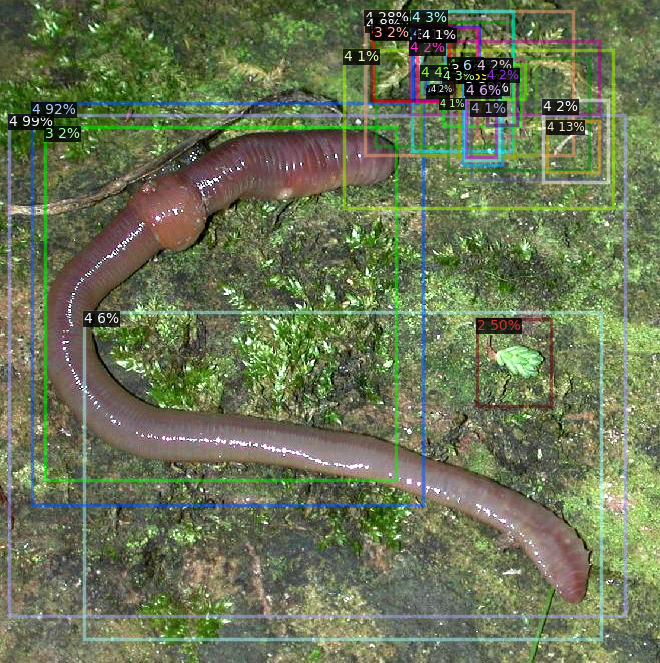

In [ ]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from google.colab.patches import cv2_imshow
import cv2

image_path = "/content/Regenwurm1.jpg"

img = cv2.imread(image_path)
if img is None:
    raise ValueError(f"Image not found: {image_path}")

outputs = predictor(img)

v = Visualizer(
    img[:, :, ::-1],
    metadata=None,
    scale=1.0,
    instance_mode=ColorMode.IMAGE
)
instances = outputs["instances"].to("cpu")
pred_classes = instances.pred_classes
scores = instances.scores

for cls_id, score in zip(pred_classes, scores):
    print(f"Class: {CLASSES[int(cls_id)]}, Score: {score:.3f}")
print("Predicted class IDs:", pred_classes)
print("Confidence scores:", scores)

out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])